# <font color="blue"> Cuaderno 14: Autoencoders en Redes Neuronales </font>

# Introducción a los Autoencoders

Este cuaderno tiene como objetivo introducir el concepto de **autoencoders**, explicar cómo se construyen utilizando redes neuronales y documentar tres ejemplos prácticos:

- Autoencoder básico  
- Eliminación de ruido en imágenes  
- Detección de anomalías  

---

## ¿Qué son los Autoencoders?

Los **autoencoders** son un tipo de red neuronal que pertenece al campo del **aprendizaje no supervisado**. Su principal objetivo es aprender una representación eficiente y comprimida de los datos de entrada mediante un proceso de **codificación y decodificación**.

### Componentes principales:

- **Codificador (Encoder):** comprime la entrada en una representación de menor dimensión conocida como *espacio latente*.
- **Decodificador (Decoder):** reconstruye la entrada original a partir de esa representación comprimida.

---

## ¿Para qué se utilizan?

Los autoencoders se aplican en tareas como:

- Reducción de dimensionalidad  
- Compresión de datos  
- Eliminación de ruido  
- Detección de anomalías  
- Generación de datos sintéticos (en variantes como los *Variational Autoencoders*)

---

## ¿Cómo se implementan con redes neuronales?

Un autoencoder está compuesto por dos bloques principales:

### 🔹 Codificador (Encoder)

Una serie de capas (densas, convolucionales, etc.) que transforman los datos de entrada en una representación más compacta. Esta salida se conoce como **espacio latente (latent space)**, y es clave porque captura las características más relevantes del dato original.

### 🔹 Decodificador (Decoder)

Toma el vector del espacio latente y trata de **reconstruir la entrada original**. El entrenamiento se basa en minimizar la diferencia entre la entrada y la salida reconstruida, generalmente usando **Mean Squared Error (MSE)** como función de pérdida.

---

## Arquitectura básica

Un autoencoder básico puede construirse usando capas densas (*fully connected*), pero también pueden usarse **redes convolucionales (CNNs)** para datos como imágenes, donde es importante conservar la estructura espacial.

---

## Espacio Latente (Latent Space)

El **espacio latente** es la representación comprimida que produce el codificador. Esta representación:

- Reduce la dimensionalidad de los datos  
- Conserva la información más importante  
- Permite detectar patrones y anomalías  
- Puede visualizarse en 2D/3D usando técnicas como **t-SNE** o **PCA**

Además, puede utilizarse para tareas avanzadas como interpolación entre ejemplos o generación de nuevas muestras similares.

---


Un autoencoder básico puede consistir en capas densas (fully connected layers), pero también se pueden usar otras estructuras como redes convolucionales para tareas más complejas.

![](https://contenthub-static.grammarly.com/blog/wp-content/uploads/2024/10/6303_blog-visuals-auto-encoders_1500X800.png)
---

## Usos y Ventajas de los Autoencoders

1. **Reducción de Dimensionalidad**: Similar al Análisis de Componentes Principales (PCA), los autoencoders pueden reducir las dimensiones de los datos mientras retienen la mayor parte de la información.
2. **Compresión de Datos**: Pueden comprimir datos y almacenar solo la representación compacta.
3. **Eliminación de Ruido**: Se pueden entrenar para eliminar ruido de las imágenes, como veremos más adelante.
4. **Detección de Anomalías**: Los autoencoders pueden detectar patrones inusuales o outliers al comparar la entrada con la salida reconstruida.
5. **Generación de Datos**: Autoencoders como los Variational Autoencoders (VAEs) pueden generar nuevos ejemplos de datos.



Un ejemplo de diseño de la red neruonal Autoencoder es la siguiente:

```python
# Ejemplo básico de estructura (con Keras)
from keras.models import Model
from keras.layers import Input, Dense

# Codificador
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)  # espacio latente

# Decodificador
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
output_img = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_img, outputs=output_img)
autoencoder.compile(optimizer='adam', loss='mse')
```

```python
#Otra forma es esta
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

autoencoder = Sequential()
autoencoder.add(Input(shape=(784,)))  # Entrada
# Codificador
autoencoder.add(Dense(128, activation='relu'))
autoencoder.add(Dense(64, activation='relu'))
autoencoder.add(Dense(32, activation='relu'))  # Espacio latente
# Decodificador
autoencoder.add(Dense(64, activation='relu'))
autoencoder.add(Dense(128, activation='relu'))
autoencoder.add(Dense(784, activation='sigmoid'))  # Salida

autoencoder.compile(optimizer='adam', loss='mse'
```

## <font color="blue"> Ejemplo 1: Autoencoder Básico conjunto de datos Fashion MNIST</font>

A continuación, implementaremos un autoencoder básico utilizando el conjunto de datos **Fashion MNIST**. Este conjunto contiene imágenes de 28x28 píxeles de diferentes tipos de ropa.

1. Primero cargamos los datos y normalizamos las imágenes.
2. Creamos el modelo con un codificador y decodificador simples.
3. Entrenamos el modelo y mostramos cómo el autoencoder reconstruye las imágenes.


## Importar TensorFlow y otras bibliotecas

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

## Cargue el conjunto de datos
Para comenzar, entrenará el codificador automático básico utilizando el conjunto de datos Fashion MNIST. Cada imagen en este conjunto de datos tiene 28x28 píxeles.

. Se Cargaron en el dataset de fashion_mnist, con  60,000 imágenes de entrenamiento y 10,000 de prueba.

* Se ignoran las etiquetas (_) porque el autoencoder no necesita saber qué clase es cada imagen, solo quiere reconstruirlas.

* **Normaliza los datos:**

Convierte de enteros uint8 (0-255) a float32 y los escala a valores entre 0.0 y 1.0. Esto es esencial para entrenar redes neuronales de forma eficiente.

* **Imprime las formas (shapes) de los datos:**

x_train.shape = (60000, 28, 28)
x_test.shape = (10000, 28, 28)

Esto confirma que tienes 60k imágenes de entrenamiento y 10k de prueba, cada una de 28×28 píxeles.



In [2]:
(x_train, y_train), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print (x_train.shape)
print (x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [3]:
# Nombres de las clases (labels)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Ejemplo: mostrar primeras 5 etiquetas con sus nombres
for i in range(5):
    print(f"Etiqueta numérica: {y_train[i]}, Nombre: {class_names[y_train[i]]}")

Etiqueta numérica: 9, Nombre: Ankle boot
Etiqueta numérica: 0, Nombre: T-shirt/top
Etiqueta numérica: 0, Nombre: T-shirt/top
Etiqueta numérica: 3, Nombre: Dress
Etiqueta numérica: 0, Nombre: T-shirt/top


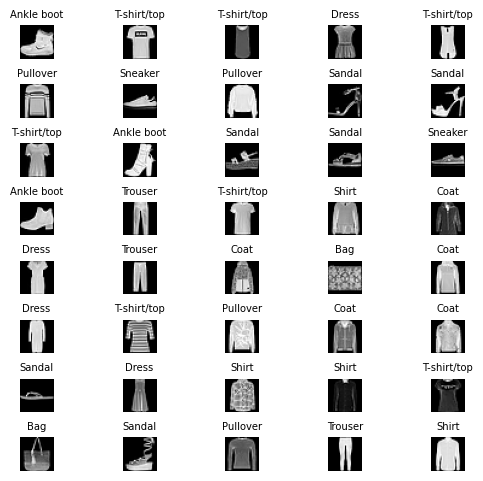

In [4]:
import matplotlib.pyplot as plt

# Mostrar las primeras 10 imágenes del set de entrenamiento
#cambiar tamaño de letra
plt.rcParams['font.size'] = 6
for i in range(40):
    plt.subplot(8, 5, i + 1)         # 2 filas, 5 columnas
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])

    plt.axis('off')
    plt.tight_layout()
plt.show()


#Autoencoder híbrido (Conv2D + Dense en el centro)

Se usa Conv2D, MaxPooling2D, UpSampling2D si se está trabajando directamente con imágenes.

Solo se usa Dense si necesitas compactar a un vector o hacer algo especial en el latent space.

Lo ideal muchas veces es un híbrido: convolucional al inicio/final, y denso en el centro (latente).

Este es el ejemplo que vamos hacer:
![](https://github.com/adiacla/bigdata/blob/master/autoencoderImg.png?raw=true)


## 🔍 Explicación del Autoencoder Híbrido (Conv2D + Dense)

Este modelo es un autoencoder diseñado para imágenes de tamaño **28x28x1** (por ejemplo, del dataset Fashion MNIST). Se compone de tres partes principales: **Encoder, Vector Latente y Decoder**. Usa tanto capas convolucionales como densas para aprender representaciones compactas.

---

### **Encoder**
El encoder convierte la imagen en una representación comprimida:

- `Conv2D(32)` → extrae 32 mapas de características con filtro 3x3.
- `MaxPooling2D` → reduce resolución a la mitad (28x28 → 14x14).
- `Conv2D(64)` → extrae características más profundas.
- `MaxPooling2D` → reduce resolución a 7x7, manteniendo 64 canales.

---

### **Latent Space (Vector latente)**
- `Flatten` → convierte el tensor 7x7x64 en un vector de 3136 elementos.
- `Dense(64)` → capa densa que reduce la información a un vector de **64 dimensiones**, que representa la **codificación comprimida** de la imagen.

---

### **Decoder**
Reconstruye la imagen original desde el vector latente:

- `Dense(3136)` → expande el vector a su forma original.
- `Reshape(7x7x64)` → lo vuelve a transformar a una estructura espacial.
- `UpSampling2D` → aumenta la resolución de nuevo a 14x14, luego a 28x28.
- `Conv2D(64)` y `Conv2D(32)` → refinan la reconstrucción.
- `Conv2D(1, activation='sigmoid')` → genera la imagen final reconstruida (28x28x1), con valores entre 0 y 1.

---

### **Compilación**
El modelo se compila con:
- `optimizer='adam'`: optimizador eficiente y adaptativo.
- `loss='binary_crossentropy'`: apropiado para reconstrucción de imágenes binarizadas o normalizadas entre 0 y 1.

---

Este diseño **híbrido** permite una representación eficiente y flexible, combinando lo mejor de las capas convolucionales (estructura espacial) y densas (compresión global).


In [5]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers # Importar optimizers

# Entrada de imagen (28x28x1)
entrada = Input(shape=(28, 28, 1), name="entrada")

# --- ENCODER ---
x = Conv2D(32, (3, 3), activation='relu', padding='same')(entrada)     # 28x28x32
x = MaxPooling2D((2, 2), padding='same')(x)                            # 14x14x32
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)          # 14x14x64
x = MaxPooling2D((2, 2), padding='same')(x)                            # 7x7x64

# A vector (Flatten) + Dense (cuello de botella)
x = Flatten()(x)                                                      # 7*7*64 = 3136
encoded = Dense(64, activation='relu', name='latent_vector')(x)       # Vector latente

# --- DECODER ---
x = Dense(7*7*64, activation='relu')(encoded)                         # Expansión
x = Reshape((7, 7, 64))(x)                                            # De vuelta a 3D
x = UpSampling2D((2, 2))(x)                                           # 14x14x64
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)                                           # 28x28x64
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)

# Salida final (una imagen 28x28x1)
salida = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='salida')(x)

# Definir modelo
autoencoder = Model(inputs=entrada, outputs=salida)

# Definir el optimizador Adam con una tasa de aprendizaje específica
custom_adam = optimizers.Adam(learning_rate=0.0001) # Puedes cambiar 0.0001 al valor que desees

# Compilar el modelo usando el optimizador configurado
autoencoder.compile(optimizer=custom_adam, loss=losses.MeanSquaredError())

Cuando aplicas una operación de convolución a una imagen, los píxeles en los bordes se ven menos veces por el filtro que los píxeles en el centro. Esto puede llevar a que la capa de salida sea ligeramente más pequeña que la entrada original.

**padding='same'** resuelve esto añadiendo automáticamente un número de píxeles (generalmente ceros) alrededor de los bordes de la imagen de entrada antes de aplicar la convolución. **La cantidad de padding se calcula de manera que la capa de salida tenga exactamente las mismas dimensiones espaciales (alto y ancho) que la capa de entrada**, asumiendo que el stride (paso) es 1.


¿Qué hace UpSampling2D?

UpSampling2D es una capa simple pero efectiva que aumenta las dimensiones espaciales (alto y ancho) de su entrada. Lo hace repitiendo las filas y columnas de los mapas de características.

¿Cómo funciona?

Imagina que tienes una pequeña matriz de píxeles, por ejemplo, de 2x2:

[1, 2],

[3, 4]

Si aplicas un UpSampling2D con un size=(2, 2), la capa duplica cada fila y cada columna:

Duplicar filas:

[[1, 2],

 [1, 2],

 [3, 4],

 [3, 4]]
Duplicar columnas:

[[1, 1, 2, 2],

 [1, 1, 2, 2],

 [3, 3, 4, 4],

 [3, 3, 4, 4]]

El resultado es una matriz de 4x4. En este caso, el tamaño se duplicó en ambas dimensiones.


Entrene el modelo usando x_train como entrada y como destino. El encoder aprenderá a comprimir el conjunto de datos de 784 dimensiones al espacio latente, y el decoder aprenderá a reconstruir las imágenes originales.

**Reshape((7, 7, 64))(x)** convierte el vector 1D largo de vuelta a una forma 3D (7x7x64) para que las capas convolucionales y de upsampling del Decoder puedan seguir trabajando con una estructura de imagen. No cambia los valores, solo su organización.

Durante el entrenamiento de una red neuronal, los datos de entrenamiento se dividen en pequeños grupos llamados lotes (batches). El modelo aprende procesando un lote a la vez y ajustando sus pesos después de cada lote.

Cuando shuffle=True, Keras mezcla aleatoriamente el orden de los datos de entrenamiento al principio de cada época.

En Keras, el valor por defecto para el batch_size en el método model.fit() es 32.



Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 0.0468 - val_loss: 0.0159
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0148 - val_loss: 0.0126
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0121 - val_loss: 0.0111
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0107 - val_loss: 0.0101
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0098 - val_loss: 0.0094
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0092 - val_loss: 0.0089
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0087 - val_loss: 0.0084
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0082 - val_loss: 0.0081
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0079 - val_loss: 0.0078
Epoch 10/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0077 - val_loss: 0.0075
Epoch 11/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0074 - val_loss: 0.0073
Epoch 12/40
1875/1875 ━━━━━━━

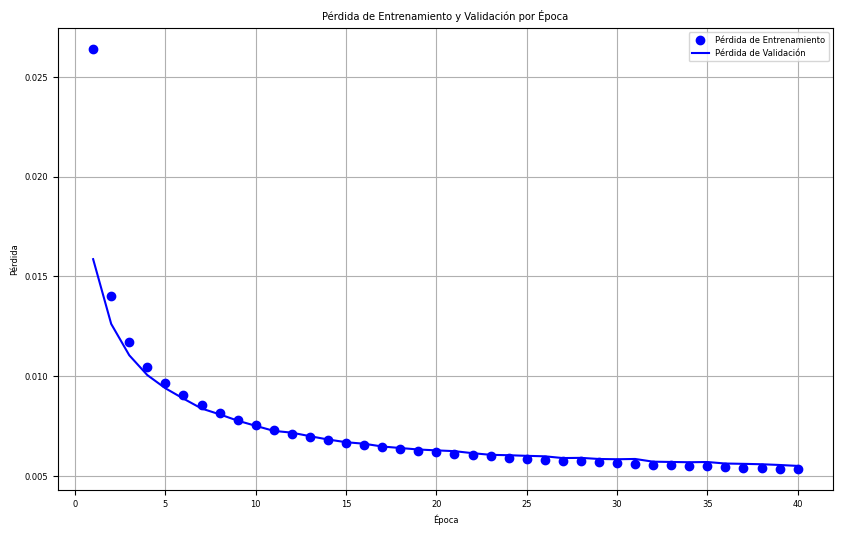

In [6]:
import matplotlib.pyplot as plt

# El método fit devuelve un objeto History
history = autoencoder.fit(x_train, x_train,
                          epochs=40,
                          shuffle=True,
                          validation_data=(x_test, x_test))

# Obtener los valores de pérdida del historial de entrenamiento
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# Trazar las curvas de pérdida
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación por Época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


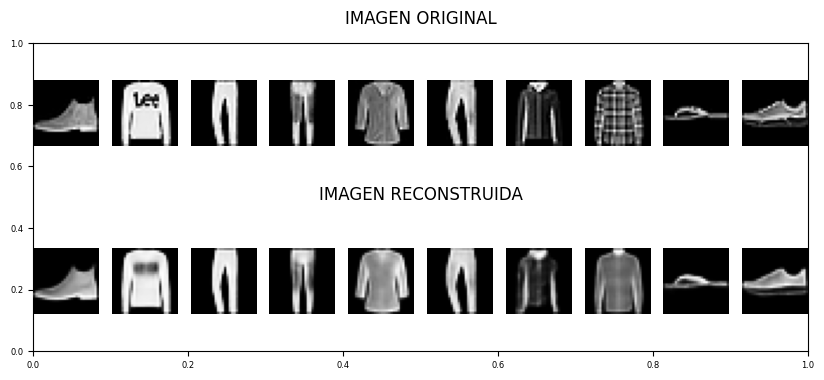

In [7]:
# --- Codificar y decodificar las imágenes ---
# Vamos a usar el modelo autoencoder ya entrenado para obtener las reconstrucciones
decoded_imgs = autoencoder.predict(x_test)

# Mostrar las primeras 10 imágenes comparando las originales y las reconstruidas
plt.figure(figsize=(10, 4))

# Añadir títulos para las filas
plt.text(0.5, 1.05, 'IMAGEN ORIGINAL', horizontalalignment='center', verticalalignment='bottom', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.5, 0.48, 'IMAGEN RECONSTRUIDA', horizontalalignment='center', verticalalignment='bottom', transform=plt.gca().transAxes, fontsize=12)


for i in range(10):
    # Original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off') # Corregido: usar 'off' para ocultar los ejes

    # Reconstruida
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off') # Corregido: usar 'off' para ocultar los ejes

plt.show()

## <font color="blue"> Ejemplo 2: Eliminación de Ruido en Imágenes </font>

![](https://github.com/adiacla/bigdata/blob/master/autoencoderImgruido.png?raw=true)

En este taller, crearemos un autoencoder que eliminará el ruido de las imágenes de Fashion MNIST.

    Agregamos ruido a las imágenes.
    Creamos un autoencoder convolucional para reconstruir las imágenes originales.
    Comprobamos los resultados.

![Image denoising results](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/image_denoise_fmnist_results.png?raw=1)

Vamos a entrenar un codificador automático para eliminar el ruido de las imágenes. En la siguiente sección, creará una versión ruidosa del conjunto de datos Fashion MNIST aplicando ruido aleatorio a cada imagen. Luego entrenará un codificador automático utilizando la imagen ruidosa como entrada y la imagen original como objetivo.

Volvamos a importar el conjunto de datos para omitir las modificaciones realizadas anteriormente.

In [8]:
#Descagamos otra vez los datos
(x_train, _), (x_test, _) = fashion_mnist.load_data()

In [9]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(x_train.shape)

(60000, 28, 28, 1)



**Agregar ruido aleatorio a las imágenes**

Este código simula imágenes con ruido, añadiendo ruido gaussiano controlado a las imágenes originales. Es útil para entrenar autoencoders en tareas de eliminación de ruido (denoising autoencoders), donde el modelo aprende a restaurar imágenes limpias a partir de versiones ruidosas.


Este proceso de añadir ruido es una técnica común en el aprendizaje no supervisado, ya que mejora la capacidad del modelo para generalizar y hacer predicciones más robustas en datos ruidosos.


La operación tf.clip_by_value() asegura que los valores de los píxeles ruidosos estén dentro del rango válido para imágenes normalizadas (0 a 1).

Si algún píxel tiene un valor fuera de este rango debido al ruido, se recorta para que quede dentro de los límites establecidos (clip_value_min=0. y clip_value_max=1.).

In [10]:
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

Veamos las imágenes ruidosas.

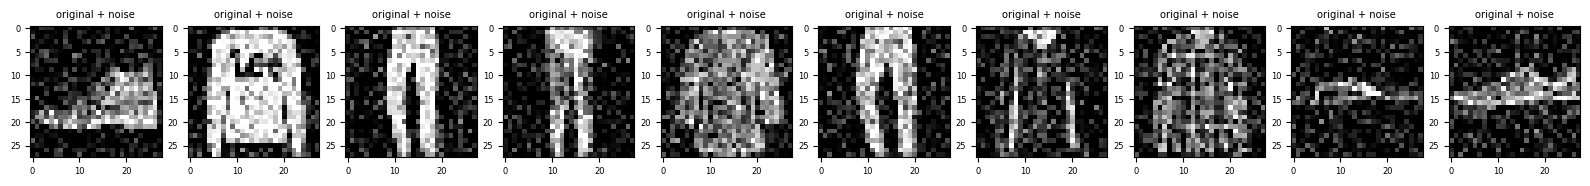

In [11]:
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
plt.show()

### Definir un codificador automático convolucional

Definir un codificador automático convolucional
En este ejemplo, entrenará un codificador automático convolucional utilizando capas Conv2D en el encoder y capas Conv2DTranspose en el decoder .

In [12]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Dense, Flatten, Reshape
from tensorflow.keras.models import Model

# Entrada de imagen (28x28x1)
entrada = Input(shape=(28, 28, 1), name="entrada")

# --- ENCODER ---
x = Conv2D(32, (3, 3), activation='relu', padding='same')(entrada)     # 28x28x32
x = MaxPooling2D((2, 2), padding='same')(x)                            # 14x14x32
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)          # 14x14x64
x = MaxPooling2D((2, 2), padding='same')(x)                            # 7x7x64

# A vector (Flatten) + Dense (cuello de botella)
x = Flatten()(x)                                                      # 7*7*64 = 3136
encoded = Dense(64, activation='relu', name='latent_vector')(x)       # Vector latente

# --- DECODER ---
x = Dense(7*7*64, activation='relu')(encoded)                         # Expansión
x = Reshape((7, 7, 64))(x)                                            # De vuelta a 3D
x = UpSampling2D((2, 2))(x)                                           # 14x14x64
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)                                           # 28x28x64
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)

# Salida final (una imagen 28x28x1)
salida = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='salida')(x)

# Definir modelo
autoencoderruido = Model(inputs=entrada, outputs=salida)


In [13]:

autoencoderruido.compile(optimizer='adam', loss='binary_crossentropy')


In [14]:
history_denoising = autoencoderruido.fit(
    x=x_train_noisy,              # Imágenes con ruido como entrada
    y=x_train,                    # Imágenes originales como objetivo
    epochs=20,                    # Número de épocas
    batch_size=128,               # Tamaño del lote
    shuffle=True,                 # Mezcla aleatoria en cada época
    validation_data=(x_test_noisy, x_test),  # Validación: ruido como entrada, imagen limpia como salida
    verbose=1                     # Muestra progreso del entrenamiento
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 0.3930 - val_loss: 0.2951
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2906 - val_loss: 0.2869
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2846 - val_loss: 0.2839
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2805 - val_loss: 0.2821
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2784 - val_loss: 0.2799
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2771 - val_loss: 0.2788
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2767 - val_loss: 0.2779
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2756 - val_loss: 0.2773
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2749 - val_loss: 0.2772
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2745 - val_loss: 0.2766
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2735 - val_loss: 0.2764
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


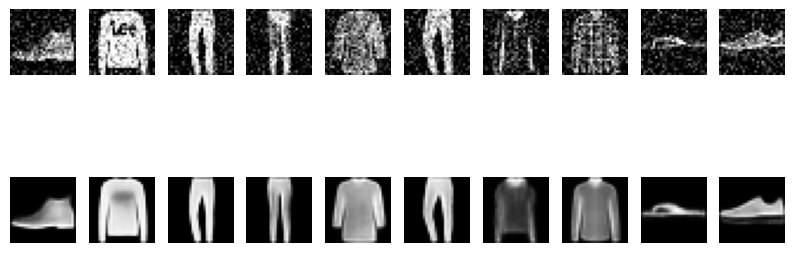

In [15]:
# Vamos a usar el modelo autoencoder ya entrenado para obtener las reconstrucciones
decoded_imgs = autoencoderruido.predict(x_test_noisy)

# Mostrar las primeras 10 imágenes comparando las originales y las reconstruidas
plt.figure(figsize=(10, 4))
for i in range(10):
    # Original ruidosa
    ax = plt.subplot(2, 10, i + 1)
    # Convert EagerTensor to NumPy array before reshape
    plt.imshow(x_test_noisy[i].numpy().reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Imagen reconstruida
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

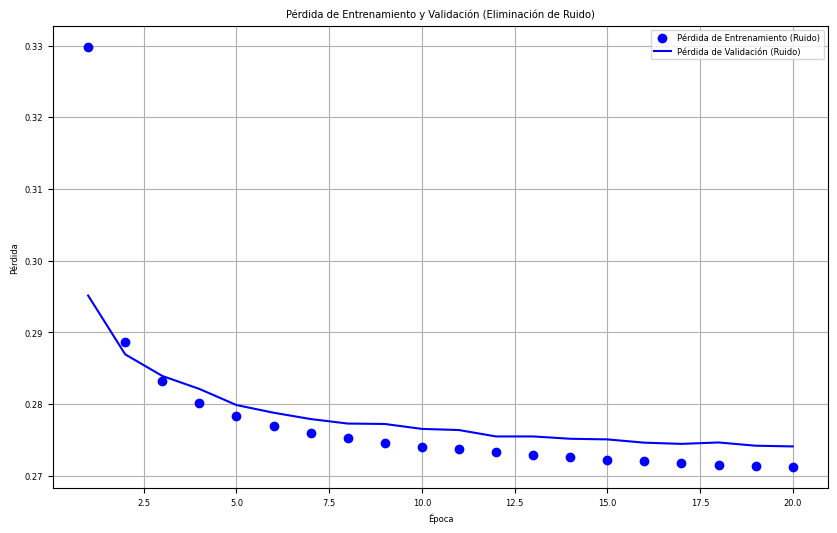

In [16]:
import matplotlib.pyplot as plt

loss_denoising = history_denoising.history['loss']
val_loss_denoising = history_denoising.history['val_loss']
epochs_denoising = range(1, len(loss_denoising) + 1)

# Trazar las curvas de pérdida para el autoencoder de eliminación de ruido
plt.figure(figsize=(10, 6))
plt.plot(epochs_denoising, loss_denoising, 'bo', label='Pérdida de Entrenamiento (Ruido)')
plt.plot(epochs_denoising, val_loss_denoising, 'b', label='Pérdida de Validación (Ruido)')
plt.title('Pérdida de Entrenamiento y Validación (Eliminación de Ruido)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()